# Wine Price Prediction: Embedding Ridge Stacking + CatBoost

`description` のembeddingをCatBoostへ直接投入せず、Ridge回帰で $\log(\mathrm{price})$ のOOF予測値1列に集約します。その予測値を `points` およびカテゴリ変数とともにCatBoostへ入力します。

### 実行コードの説明

CatBoostが未導入の実行環境を想定し、`pip` でパッケージをインストールする。このセルは依存パッケージの準備だけを行い、モデルの学習やデータの変更は行わない。


In [13]:
!pip install -q -U catboost

### ライブラリと乱数シードを準備するコード

ファイル操作、データ処理、可視化、GPU確認、文章embedding、Ridge回帰、CatBoost、交差検証、評価指標に必要なライブラリを読み込む。`KFold` はOOF予測の5分割、`Ridge` はembeddingを1つの価格予測値へ集約するために使用する。乱数シードを42に固定して再現性を確保する。


In [14]:
# 必要なライブラリが未インストールの場合のみコメントを外してください。
# %pip install -q -U sentence-transformers catboost scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from catboost import CatBoostRegressor
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split

sns.set_theme(style="whitegrid")
SEED = 42

## 1. データの読み込み

`wine_review_CatBoost.ipynb` と同じく、`title` と `description` の組で重複を除外してから価格をフィルタリングします。`title` は重複判定だけに使用します。

### 実行コードの説明

数値特徴量とカテゴリ特徴量を定義し、必要な列だけCSVから読み込む。`title` と `description` の組で重複を除外し、本文と正の価格がある行を残す。カテゴリ欠損は `__MISSING__` として保持し、読み込み元、重複削除数、モデル対象行数、先頭データを表示する。


In [15]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

numeric_features = ["points"]
categorical_features = [
    "country",
    "designation",
    "province",
    "region_1",
    "region_2",
    "variety",
    "winery",
]
feature_source_columns = ["description", "price"] + numeric_features + categorical_features
read_columns = ["title"] + feature_source_columns

df = pd.read_csv(csv_path, usecols=read_columns)
rows_before = len(df)
df = df.drop_duplicates(subset=["title", "description"]).copy()
duplicates_removed = rows_before - len(df)
model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        feature_source_columns,
    ]
    .reset_index(drop=True)
)

for column in categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype(str)

print(f"Loaded: {csv_path.resolve()}")
print(f"Removed duplicated reviews: {duplicates_removed:,}")
print(f"Rows used for modeling: {len(model_data):,}")
display(model_data.head())

Loaded: /content/data/winemag-data-130k-v2.csv
Removed duplicated reviews: 9,983
Rows used for modeling: 111,593


,description,price,points,country,designation,province,region_1,region_2,variety,winery
0,"This is ripe and fruity, a wine that is smooth...",15.0,87,Portugal,Avidagos,Douro,__MISSING__,__MISSING__,Portuguese Red,Quinta dos Avidagos
1,"Tart and snappy, the flavors of lime flesh and...",14.0,87,US,__MISSING__,Oregon,Willamette Valley,Willamette Valley,Pinot Gris,Rainstorm
2,"Pineapple rind, lemon pith and orange blossom ...",13.0,87,US,Reserve Late Harvest,Michigan,Lake Michigan Shore,__MISSING__,Riesling,St. Julian
3,"Much like the regular bottling from 2012, this...",65.0,87,US,Vintner's Reserve Wild Child Block,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Sweet Cheeks
4,Blackberry and raspberry aromas show a typical...,15.0,87,Spain,Ars In Vitro,Northern Spain,Navarra,__MISSING__,Tempranillo-Merlot,Tandem


## 2. データ分割

先に行番号を80%/10%/10%へ分割します。この分割は表形式CatBoostと同じ乱数シードを使用します。

### 実行コードの説明

行番号を固定乱数で80%の訓練、10%の検証、10%のテストへ先に分割する。この行番号を表形式特徴、embedding、目的変数に共通して使うことで対応関係を保つ。目的変数は価格の自然対数を `float32` にしたもので、各データ部分の件数も表示する。


In [16]:
all_indices = np.arange(len(model_data))
train_indices, holdout_indices = train_test_split(
    all_indices, test_size=0.2, random_state=SEED
)
valid_indices, test_indices = train_test_split(
    holdout_indices, test_size=0.5, random_state=SEED
)

y = np.log(model_data["price"].to_numpy()).astype("float32")
y_train = y[train_indices]
y_valid = y[valid_indices]
y_test = y[test_indices]

print(
    f"Train: {len(train_indices):,}, validation: {len(valid_indices):,}, "
    f"test: {len(test_indices):,}"
)

Train: 89,274, validation: 11,159, test: 11,160


## 3. 固定encoderによる128次元embedding

`mixedbread-ai/mxbai-embed-large-v1` をfine-tuningせず、Matryoshka embeddingを128次元で出力します。encoderは目的変数を使用しないため、embedding自体は一括生成できます。

### 実行コードの説明

`mixedbread-ai/mxbai-embed-large-v1` を固定encoderとして読み込み、Matryoshka表現をコード設定どおり128次元で出力する。GPUがあればCUDAを使用し、評価モードと勾配無効化によりfine-tuningを行わない。全文を64件ずつL2正規化したembeddingへ変換し、事前に作成した行番号で訓練・検証・テストへ分ける。分割後は元の一括配列を削除してメモリを解放する。


In [17]:
ENCODER_NAME = "mixedbread-ai/mxbai-embed-large-v1"
EMBEDDING_DIM = 128
BATCH_SIZE = 64

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer(
    ENCODER_NAME,
    truncate_dim=EMBEDDING_DIM,
    device=device,
)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad_(False)

embeddings = encoder.encode(
    model_data["description"].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

train_embeddings = embeddings[train_indices]
valid_embeddings = embeddings[valid_indices]
test_embeddings = embeddings[test_indices]
del embeddings

print(f"Encoder device: {device}")
print(f"Train embedding shape: {train_embeddings.shape}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/1744 [00:00<?, ?it/s]

Encoder device: cuda
Train embedding shape: (89274, 128)


## 4. RidgeによるOOF予測

訓練データを5分割し、各行についてその行を学習に使っていないRidgeモデルで予測します。validation/testは各foldモデルの予測平均を使用します。これによりCatBoostの訓練特徴量への目的変数漏洩を防ぎます。

### 実行コードの説明

訓練embeddingを5分割し、各foldで4部分を使ってRidgeを学習し、残り1部分を予測する。これを全foldで繰り返すことで、各訓練行をその行の目的変数を学習していないモデルで予測したOOF値を作る。検証・テストは5モデルの予測平均を使用する。Ridge単体のOOF訓練性能とテスト性能もRMSE、MAE、$R^2$ で表示する。


In [18]:
N_FOLDS = 5
RIDGE_ALPHA = 10.0
ridge_oof_train = np.empty(len(train_indices), dtype="float32")
ridge_valid_by_fold = np.empty((N_FOLDS, len(valid_indices)), dtype="float32")
ridge_test_by_fold = np.empty((N_FOLDS, len(test_indices)), dtype="float32")

kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for fold, (fit_positions, oof_positions) in enumerate(kfold.split(train_embeddings)):
    ridge = Ridge(alpha=RIDGE_ALPHA)
    ridge.fit(train_embeddings[fit_positions], y_train[fit_positions])
    ridge_oof_train[oof_positions] = ridge.predict(
        train_embeddings[oof_positions]
    ).astype("float32")
    ridge_valid_by_fold[fold] = ridge.predict(valid_embeddings).astype("float32")
    ridge_test_by_fold[fold] = ridge.predict(test_embeddings).astype("float32")

ridge_valid = ridge_valid_by_fold.mean(axis=0)
ridge_test = ridge_test_by_fold.mean(axis=0)

ridge_metrics = pd.DataFrame({
    "OOF train": {
        "RMSE": mean_squared_error(y_train, ridge_oof_train) ** 0.5,
        "MAE": mean_absolute_error(y_train, ridge_oof_train),
        "R2": r2_score(y_train, ridge_oof_train),
    },
    "Test": {
        "RMSE": mean_squared_error(y_test, ridge_test) ** 0.5,
        "MAE": mean_absolute_error(y_test, ridge_test),
        "R2": r2_score(y_test, ridge_test),
    },
})
display(ridge_metrics)

,OOF train,Test
RMSE,0.544682,0.550923
MAE,0.425406,0.429148
R2,0.316095,0.316654


## 5. CatBoost用特徴量

embedding 128列の代わりに、Ridgeが予測したlog価格 `description_ridge_prediction` の1列だけを追加します。

### 実行コードの説明

CatBoostへ渡す表形式特徴を訓練・検証・テストごとに取り出し、128次元embeddingそのものではなく、Ridgeが予測したlog価格を `description_ridge_prediction` という1列として追加する。訓練側にはOOF値、検証・テスト側にはfold平均値を使う。結合後はembedding配列とfold別予測配列を削除してメモリを解放する。


In [19]:
base_features = numeric_features + categorical_features
stacking_feature = "description_ridge_prediction"

X_train = model_data.iloc[train_indices][base_features].reset_index(drop=True).copy()
X_valid = model_data.iloc[valid_indices][base_features].reset_index(drop=True).copy()
X_test = model_data.iloc[test_indices][base_features].reset_index(drop=True).copy()

X_train[stacking_feature] = ridge_oof_train
X_valid[stacking_feature] = ridge_valid
X_test[stacking_feature] = ridge_test

del train_embeddings, valid_embeddings, test_embeddings
del ridge_valid_by_fold, ridge_test_by_fold

print(f"CatBoost feature matrix: {X_train.shape[1]} columns")
display(X_train.head())

CatBoost feature matrix: 9 columns


,points,country,designation,province,region_1,region_2,variety,winery,description_ridge_prediction
0,90,Australia,__MISSING__,Western Australia,Margaret River,__MISSING__,Cabernet Sauvignon-Merlot,Stella Bella,3.841153
1,89,US,White Hawk VIneyard,California,Santa Ynez Valley,Central Coast,Syrah,Pagter Brothers,3.704113
2,85,Italy,Tommaso Bojola Riserva,Tuscany,Chianti Classico,__MISSING__,Red Blend,La Castellina,3.443587
3,87,Italy,Falco Nero Riserva,Southern Italy,Salice Salentino,__MISSING__,Red Blend,Cantine De Falco,3.297397
4,80,US,Fin,California,California,California Other,Cabernet Sauvignon,Finnegan's Lake,3.132926


## 6. CatBoostの学習

表形式版との比較条件を揃えるため、CatBoostはCPUで実行します。速度を優先する場合は `CATBOOST_TASK_TYPE` を `"GPU"` に変更できますが、比較対象側も同じ設定にしてください。

### 実行コードの説明

表形式だけのCatBoostとの比較条件を揃えるためCPUを指定する。最大2,000 iteration、学習率0.05、深さ8、L2正則化5で学習し、カテゴリ列を `cat_features` として直接渡す。検証RMSEが100 iteration改善しなければ停止し、検証性能が最良だったモデルを採用する。


In [20]:
CATBOOST_TASK_TYPE = "CPU"
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=2_000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=5.0,
    random_seed=SEED,
    task_type=CATBOOST_TASK_TYPE,
    allow_writing_files=False,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100,
    use_best_model=True,
)
print(f"Best iteration: {model.get_best_iteration():,}")

0:	learn: 0.6405050	test: 0.6401837	best: 0.6401837 (0)	total: 165ms	remaining: 5m 30s
100:	learn: 0.3525926	test: 0.3365881	best: 0.3365881 (100)	total: 15.4s	remaining: 4m 50s
200:	learn: 0.3408132	test: 0.3254219	best: 0.3254219 (200)	total: 32.3s	remaining: 4m 49s
300:	learn: 0.3329111	test: 0.3189537	best: 0.3189537 (300)	total: 49.4s	remaining: 4m 39s
400:	learn: 0.3275787	test: 0.3156168	best: 0.3156168 (400)	total: 1m 9s	remaining: 4m 35s
500:	learn: 0.3228802	test: 0.3126329	best: 0.3126329 (500)	total: 1m 26s	remaining: 4m 18s
600:	learn: 0.3187651	test: 0.3103738	best: 0.3103738 (600)	total: 1m 43s	remaining: 4m 1s
700:	learn: 0.3156176	test: 0.3088234	best: 0.3088234 (700)	total: 2m 1s	remaining: 3m 45s
800:	learn: 0.3126589	test: 0.3075725	best: 0.3075725 (800)	total: 2m 19s	remaining: 3m 28s
900:	learn: 0.3101924	test: 0.3066518	best: 0.3066518 (900)	total: 2m 35s	remaining: 3m 10s
1000:	learn: 0.3079339	test: 0.3058674	best: 0.3058674 (1000)	total: 2m 53s	remaining: 2m 5

## 7. テストデータでの評価

### 実行コードの説明

モデル選択に使っていないテストデータを予測し、log価格でRMSE、MAE、$R^2$ を計算する。RMSEは大きな誤差を強く評価し、MAEは平均絶対誤差、$R^2$ はlog価格の変動を説明した割合を表す。指数変換後の実価格と予測価格から、ドル単位のMAEも計算する。


In [21]:
y_pred = model.predict(X_test)
metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, USD)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))

,value
RMSE (log price),0.301464
MAE (log price),0.220201
R2 (log price),0.795388
"MAE (price, USD)",9.342512


### 予測値と残差を可視化するコード

左図で実際のlog価格と予測log価格を比較し、45度線からの距離で誤差を確認する。右図では残差を「実際値 − 予測値」として表示する。分布の中心が0からずれていれば系統的な偏り、裾が長ければ一部の大きな予測誤差が示唆される。


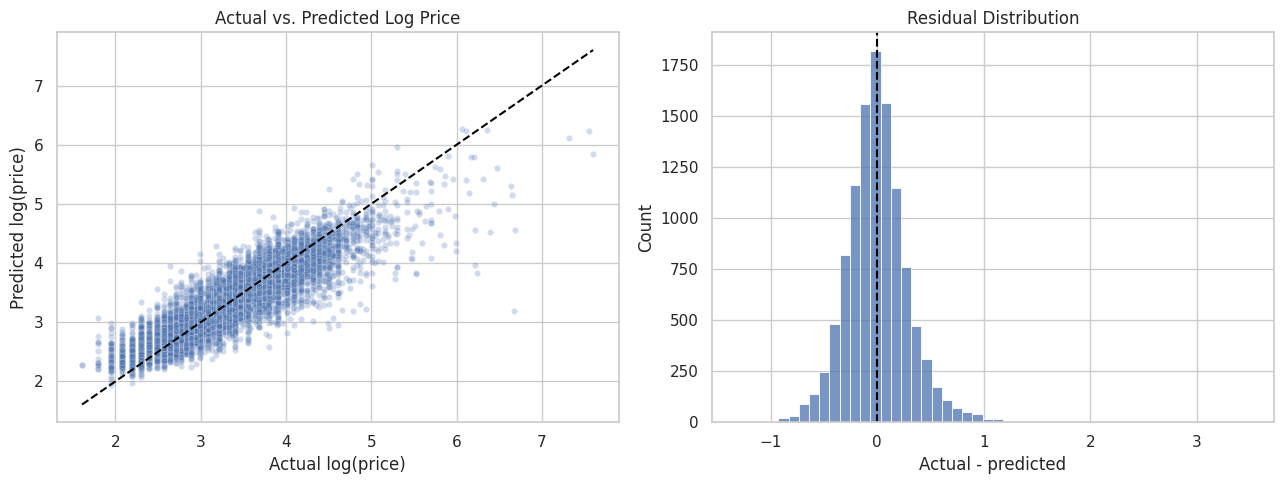

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")
plt.tight_layout()
plt.show()

## 8. 特徴量重要度

### 実行コードの説明

CatBoostから表形式特徴と `description_ridge_prediction` の重要度を取得し、高い順に表と横棒グラフで表示する。Ridge予測列の重要度を見ることで、レビュー本文から抽出した価格情報が、評価点や産地、品種、ワイナリーに対してどの程度モデルに利用されたかを確認できる。


,importance
points,22.846876
region_1,15.647805
winery,12.884425
variety,12.425235
designation,8.964739
country,8.245470
description_ridge_prediction,7.873566
province,5.663558
region_2,5.448326


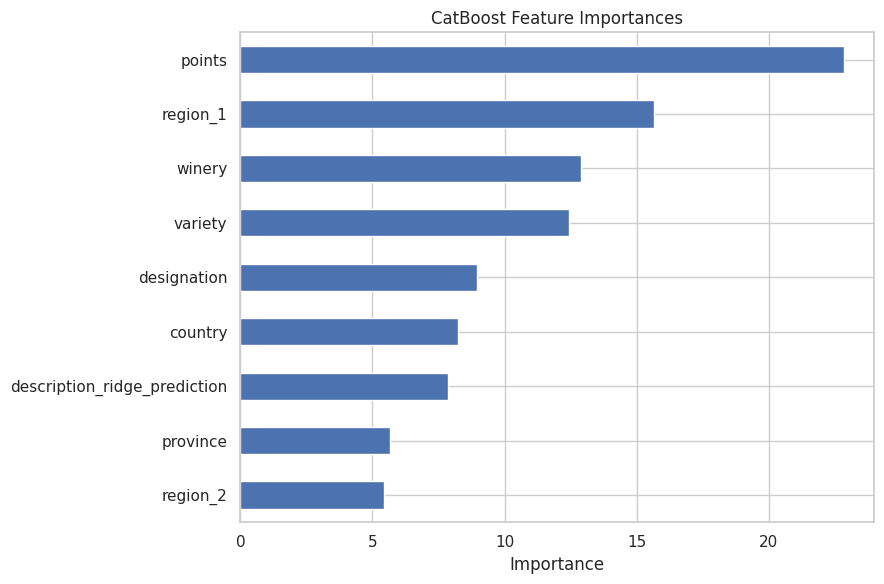

In [23]:
feature_importance = (
    pd.Series(
        model.get_feature_importance(),
        index=X_train.columns,
        name="importance",
    )
    .sort_values(ascending=False)
)
display(feature_importance.to_frame())

plt.figure(figsize=(9, 6))
feature_importance.sort_values().plot.barh()
plt.title("CatBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. 予測結果の例

### 実行コードの説明

テストデータの先頭10件について、入力特徴、実際のドル価格、予測ドル価格を並べる。log価格を指数変換して元の価格尺度に戻すことで、集約指標では分からない個別の過大・過小予測と、Ridgeによるテキスト予測値の関係を確認する。


In [24]:
prediction_examples = X_test.head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test[:10])
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)

,points,country,designation,province,region_1,region_2,variety,winery,description_ridge_prediction,actual_price,predicted_price
0,93,France,Laplace,Southwest France,Madiran,__MISSING__,Tannat,Château d'Aydie,3.486544,15.000002,35.753920
1,94,France,Schlossberg Grand Cru,Alsace,Alsace,__MISSING__,Riesling,Jean-Baptiste Adam,3.407658,54.000004,38.119563
2,93,US,Heritage,California,Livermore Valley,Central Coast,Cabernet Sauvignon,Occasio,3.773416,60.000008,46.533702
3,87,Spain,Crianza,Northern Spain,Toro,__MISSING__,Tinta de Toro,Cyan,3.263241,25.999998,18.518652
4,88,France,__MISSING__,Bordeaux,Bordeaux,__MISSING__,Bordeaux-style Red Blend,Château Arnaucosse,3.440770,10.000001,14.041624
5,89,Germany,Essence,Mosel,__MISSING__,__MISSING__,Riesling,S.A. Prüm,3.327426,12.999999,19.082912
6,89,Italy,__MISSING__,Veneto,Amarone della Valpolicella,__MISSING__,Red Blend,Tedeschi,3.789134,65.000015,49.802040
7,85,France,Tradition,Alsace,Alsace,__MISSING__,Pinot Blanc,Kuentz-Bas,2.801046,17.000000,16.632346
8,86,US,Reserve,Washington,Horse Heaven Hills,Columbia Valley,Cabernet Sauvignon,Canoe Ridge,3.369797,24.000000,24.328914
9,85,France,Le Temps des Vendanges Sauvignon Blanc-Loin de...,Southwest France,__MISSING__,__MISSING__,White Blend,Georges Vigouroux,3.348249,9.000000,13.286697


## 注意点

OOF予測はstackingにおける情報漏洩防止のために必要です。訓練embeddingへfitした単一Ridgeモデルで同じ訓練行を予測し、その値をCatBoostへ渡す方法は採用しないでください。`RIDGE_ALPHA` やembedding次元を比較する場合も、最終テストデータは選択に使わず、validation指標で決定します。